In [1]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl
%config InlineBackend.figure_format='retina'

import numpy as np
import networkx as nx
from idtxl.estimators_jidt import JidtDiscreteMI, JidtDiscreteCMI
import matplotlib.pyplot as plt
import os, sys
os.environ['JAVA_HOME'] = '/Users/jaime/miniconda3/envs/ma-aif-dit/lib/jvm'

In [2]:
%store -r all_partition_timeseries

## Krakauer et al. individuality

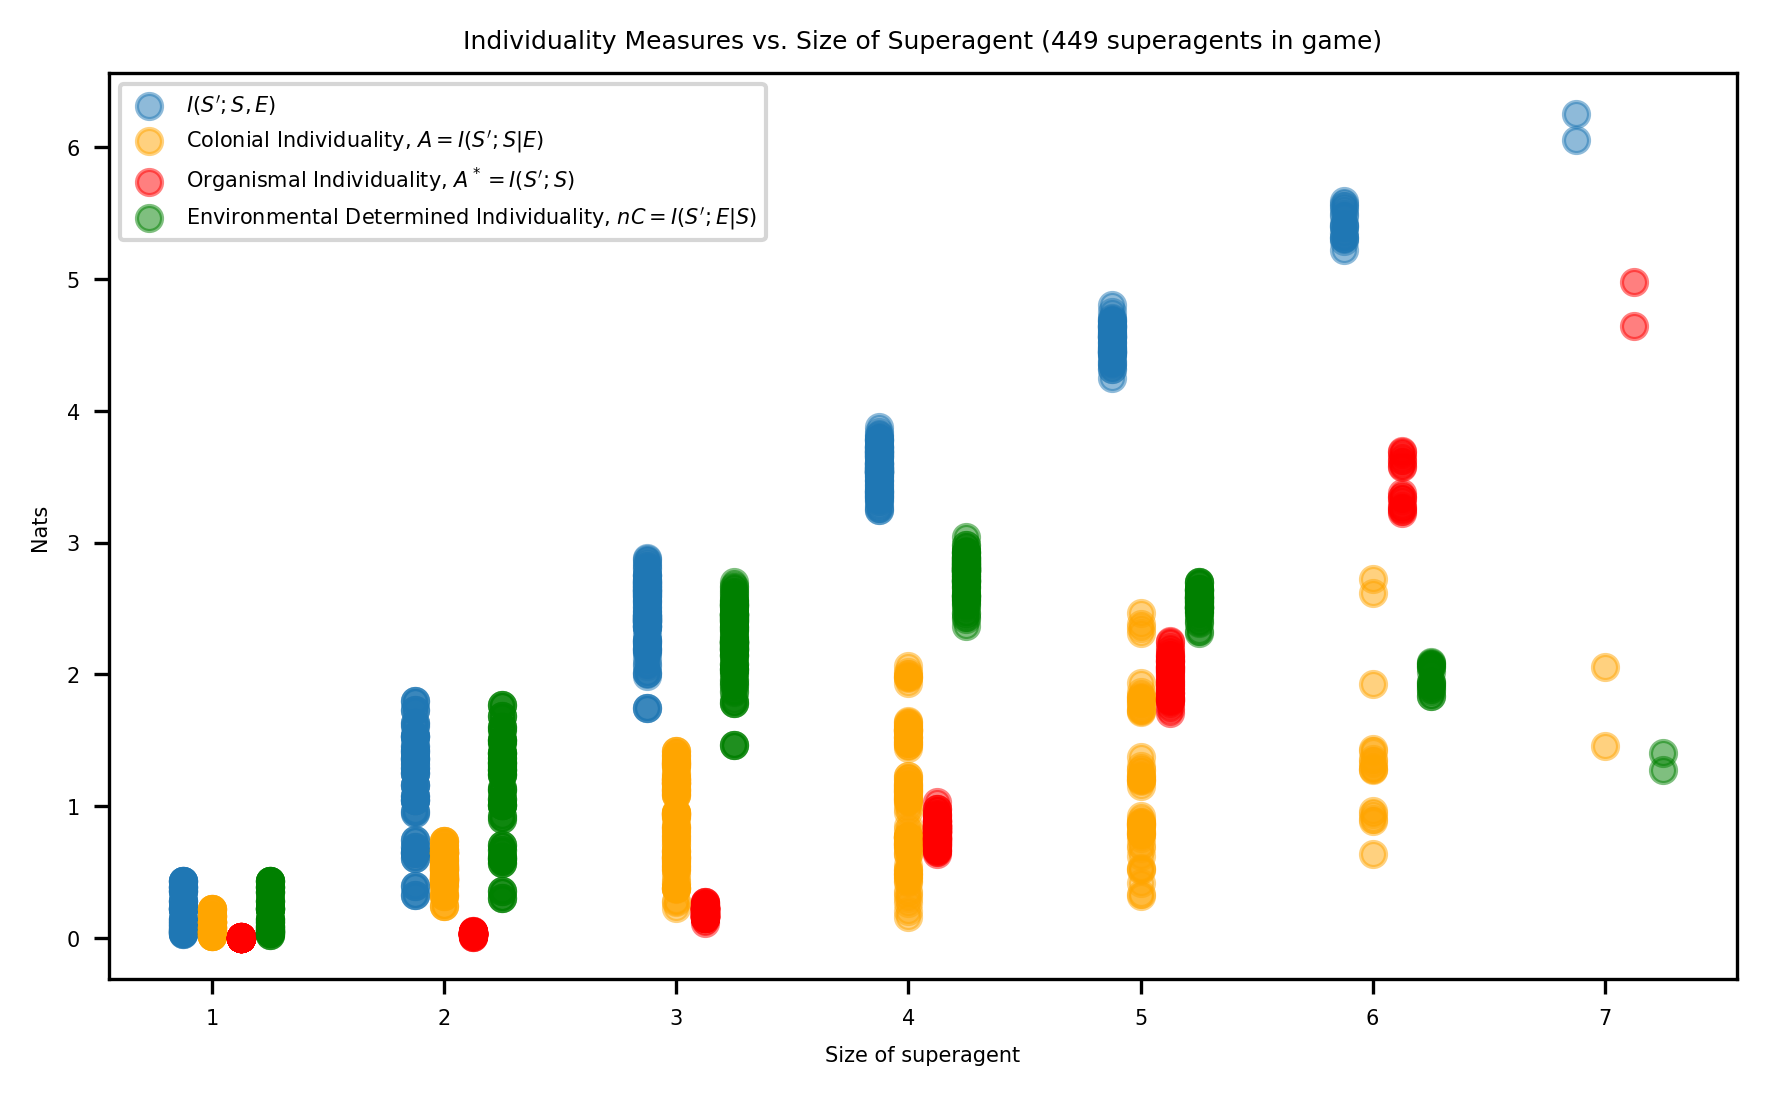

In [3]:
plt.figure(figsize=(7, 4), dpi=150)

plt.rcParams.update({'font.size': 5})

# I(S, E; S') ------------------------------------------------------------------
results_vanilla = []
for S_history, E_history in all_partition_timeseries:
    mi_estimator = JidtDiscreteMI()
    source = np.hstack((S_history[:-1], E_history[:-1]))
    target = S_history[1:]
    mi_result = mi_estimator.estimate(source, target)
    results_vanilla.append((mi_result, S_history.shape[1], E_history.shape[1]))

x = [r[1]-0.125 for r in results_vanilla]
y = [r[0] for r in results_vanilla]
plt.scatter(x, y, alpha=0.5, label="$I(S'; S, E)$")

# I(S'; S | E) --------------------------------------------------------------
results_colonial = []
for S_history, E_history in all_partition_timeseries:
    cmi_estimator = JidtDiscreteCMI()
    source = S_history[:-1]
    target = S_history[1:]
    mi_result = cmi_estimator.estimate(source, target, conditional=E_history[:-1])
    results_colonial.append((mi_result, S_history.shape[1], E_history.shape[1]))

x = [r[1] for r in results_colonial]
y = [r[0] for r in results_colonial]
plt.scatter(x, y, alpha=0.5, c='orange', label="Colonial Individuality, $A = I(S'; S | E)$")

# I(S'; S | E) --------------------------------------------------------------
results_organismal = []
for S_history, E_history in all_partition_timeseries:
    mi_estimator = JidtDiscreteMI()
    source = S_history[:-1]
    target = S_history[1:]
    mi_result = mi_estimator.estimate(source, target)
    results_organismal.append((mi_result, S_history.shape[1], E_history.shape[1]))

x = [r[1]+0.125 for r in results_organismal]
y = [r[0] for r in results_organismal]
plt.scatter(x, y, alpha=0.5, c='red', label="Organismal Individuality, $A^*=I(S' ; S)$")

# I(S'; E | S) --------------------------------------------------------------
results_environmental = []
for S_history, E_history in all_partition_timeseries:
    cmi_estimator = JidtDiscreteCMI()
    source = E_history[:-1]
    target = S_history[1:]
    mi_result = cmi_estimator.estimate(source, target, conditional=S_history[:-1])
    results_environmental.append((mi_result, S_history.shape[1], E_history.shape[1]))

x = [r[1]+0.25 for r in results_environmental]
y = [r[0] for r in results_environmental]
plt.scatter(x, y, alpha=0.5, c='green', label="Environmental Determined Individuality, $nC=I(S'; E | S)$")

# Create a scatterplot ---------------------------------------------------------
plt.legend()
plt.ylabel('Nats')
plt.xlabel('Size of superagent')
plt.title(f'Individuality Measures vs. Size of Superagent ({len(all_partition_timeseries)} superagents in game)')
plt.show()

## PID individuality

In [49]:
import pandas as pd

from dit import Distribution
from dit.pid import *

In [87]:
unique_infos = []
for S_history, E_history in all_partition_timeseries:
# S_history, E_history = all_partition_timeseries[45]
    print('superagent size', S_history.shape[1])

    # Data setup -------------------------------------------------
    all_data = np.hstack((S_history[:-1], S_history[1:], E_history[:-1], E_history[1:]))

    m = S_history.shape[1]
    if m > 4:
        # Compute struggles with larger superagents
        break

    V = all_data[:, :m].mean(axis=1)

    # Create column names for S_history and E_history
    s_columns = [f"S_{i}" for i in range(S_history.shape[1])]
    s_next_columns = [f"S_{i}_" for i in range(S_history.shape[1])]
    e_columns = [f"E_{i}" for i in range(E_history.shape[1])]
    e_next_columns = [f"E_{i}_" for i in range(E_history.shape[1])]
    column_names = s_columns + s_next_columns + e_columns + e_next_columns + ['V']

    # Combine S_history and E_history into a single DataFrame
    df = pd.DataFrame(
        np.hstack((all_data, V.reshape(-1, 1))), 
        columns=column_names
    )

    # Get distribution from DataFrame
    counts = df.value_counts()
    outcomes = list(counts.index)
    probs = list(counts / counts.sum())
    dist = Distribution(outcomes, probs)

    # Shorthand function to get the index of a column
    idx = lambda x: column_names.index(x)

    # Compute PID ------------------------------------------------------------------
    sources = [
        (idx('V'),), 
        tuple([idx(f'S_{i}') for i in range(m)]), 
    ]
    target = tuple([idx(f'S_{i}_') for i in range(m)])

    pid_obj = PID_BROJA(dist, sources, target)

    # synergy = pid_obj.get_pi(
    #     ( sources[0] + sources[1], ) 
    # )
    # redundancy = pid_obj.get_red(tuple(sources))

    # TODO: level-k
    unique_info = pid_obj.get_pi(
        (sources[1], )
    )
    # unique_info = pid_obj.get_pi(
        # (tuple([idx(f'S_{i}_') for i in range(m)]), )
    # )

    # unique_infos = np.empty((2,))
    # for i in range(2):
    #     unique_infos[i] = pid_obj.get_pi(((i,),))

    # Also compute total MI (sum synergy, redundancy, unique X1, unique X2)
    # total_mi = (
    #     synergy
    #     + redundancy
    #     + unique_infos.sum()
    # )
    unique_infos.append(unique_info)

superagent size 1
superagent size 1
superagent size 1
superagent size 1
superagent size 1
superagent size 1
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 2
superagent size 3
superagent size 3
superagent size 3
superagent size 3
superagent size 3
superagent size 3
superagent size 3
superagent size 3
superagent size 3
superagent size 3
superagent size 4


KeyboardInterrupt: 

In [88]:
label_font_size = 6

# matplotlib.use("pgf")
plt.rcParams.update({
    'xtick.labelsize': label_font_size,
    'ytick.labelsize': label_font_size,
    'axes.linewidth': 0.5,
    'font.family': 'serif',
    'text.usetex': True,
    'text.latex.preamble': r'''
        \usepackage{amssymb} 
        \usepackage{amsmath} 

        % Load Libertine fonts for text and math
        \usepackage[tt=false]{libertine}   % Libertine for text (not for monospaced)
        \usepackage[libertine]{newtxmath}  % Libertine for math

        % Load Inconsolata for monospaced text
        \usepackage{inconsolata}

        % Redefine \mathtt to use Inconsolata in math mode
        \renewcommand{\mathtt}[1]{\text{\texttt{#1}}}
    ''',
    'figure.dpi': 300,
    'pgf.texsystem': 'pdflatex',
    'pgf.rcfonts': False,
    'ps.usedistiller': 'xpdf',
})

Text(0.5, 1.0, 'Unique Information vs. Size of Superagent (data for only 23 superagents)')

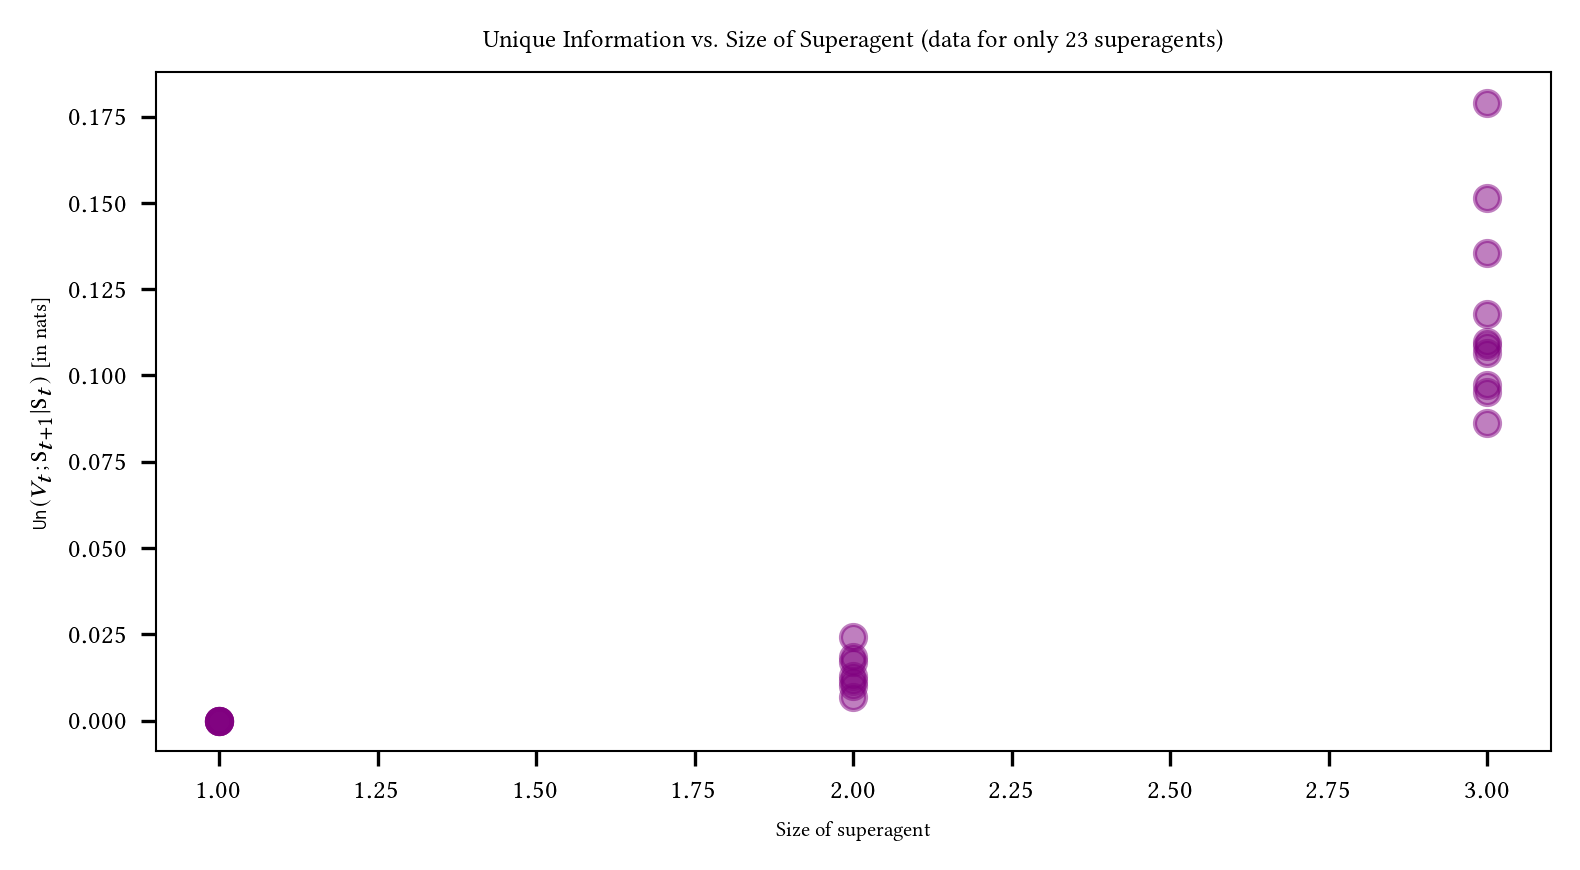

In [89]:
superagent_sizes = np.array([s.shape[1] for s, e in all_partition_timeseries])
plt.figure(figsize=(6, 3), dpi=150)
plt.scatter(
    superagent_sizes[:len(unique_infos)], 
    unique_infos, 
    alpha=0.5, 
    c='purple', 
    label="Unique Information"
)
plt.xlabel('Size of superagent')
plt.ylabel(r'$\texttt{Un}(V_t; \mathbf{S}_{t+1} | \mathbf{S}_t)$ [in nats]')
plt.title(f'Unique Information vs. Size of Superagent (data for only {len(unique_infos)} superagents)')

In [48]:
unique_info

4.440892098500626e-16